In [4]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as p
import numpy as np
import flamingo_analysis as fa 
import tangos as db
import flamingo_tangos as ft

db.init_db('data.db')


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
# check for the following timestep:
ts_name = '%720%FID%/%4%'

<>:24: SyntaxWarning: invalid escape sequence '\d'
<>:24: SyntaxWarning: invalid escape sequence '\d'
/var/folders/vk/zg9_2k_512l3syhc8kdzkzwm0000gp/T/ipykernel_83730/481921283.py:24: SyntaxWarning: invalid escape sequence '\d'
  p.ylabel("$\dot{r}_{200m}$ [kpc/yr]")


(((M200m() - earlier(1).M200m())/(777285400.0000002))-(at(0.0, all_mdot_r200m_relative)))/(((at(0.1, all_mass_enclosed_r200m_relative) - at(-0.1, all_mass_enclosed_r200m_relative)) / (r200m * 10**0.1 - r200m * 10**-0.1)))


[]

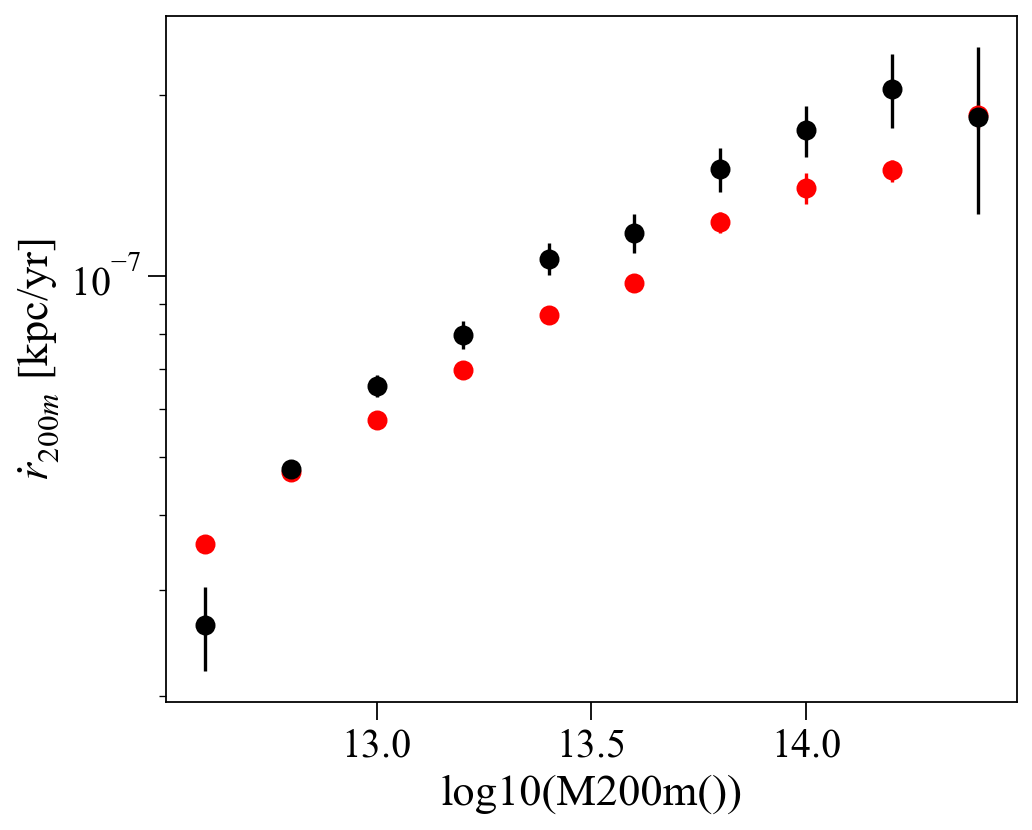

In [6]:
# CHECK \dot{M}_{200m} = \dot{M}|_{r200m} + dM/dr|_{r200m} * \dot{r}_{200m}, using
# discrete time difference for \dot{r}_200m and \dot{M}_{200m}.
#
# Solve for \dot{r}_{200m} to get an expression we can plot and compare with the discrete one.

delta_t_yr = (db.get_timestep(ts_name).time_gyr - db.get_timestep(ts_name).previous.time_gyr)*1e9

dMdR_expr = f'((at(0.1, all_mass_enclosed_r200m_relative) - at(-0.1, all_mass_enclosed_r200m_relative)) / (r200m * 10**0.1 - r200m * 10**-0.1))'

# rdot
fa.make_binned_by_mass_plot(f'(r200m - earlier(1).r200m)/{delta_t_yr}', plot_kwargs={'color': 'red'}, ts_name = ts_name, error_range='uncertainty', num_bins=10)

M200m_dot_expr = f'(M200m() - earlier(1).M200m())/({delta_t_yr})'
Mdot_expr = 'at(0.0, all_mdot_r200m_relative)'

print(f'(({M200m_dot_expr})-({Mdot_expr}))/({dMdR_expr})')

# our expression for rdot from flow rates etc
# note the + sign because Mdot is negative for inflow
fa.make_binned_by_mass_plot(f'(({M200m_dot_expr})+({Mdot_expr}))/({dMdR_expr})', 
                            plot_kwargs={'color': 'black'}, ts_name = ts_name, error_range='uncertainty', num_bins=10)

p.title("")
p.ylabel("$\dot{r}_{200m}$ [kpc/yr]")
p.semilogy()

 z_early: 0.09999999999999987, z_late: 0.0 
 delta log rho_m: -0.2859305394129743 
 -3H(z) * delta_t: -0.2929711184729324 
 delta(ln a^3): 0.2859305394129742 
3.0 * M200m() * ( (r200m - earlier(1).r200m) / (r200m * 1337058230.0000002) ) + (M200m()*-2.191161999525872e-10)


Text(0, 0.5, '$\\dot{M}_{200m}$ [M$_\\odot$/yr]')

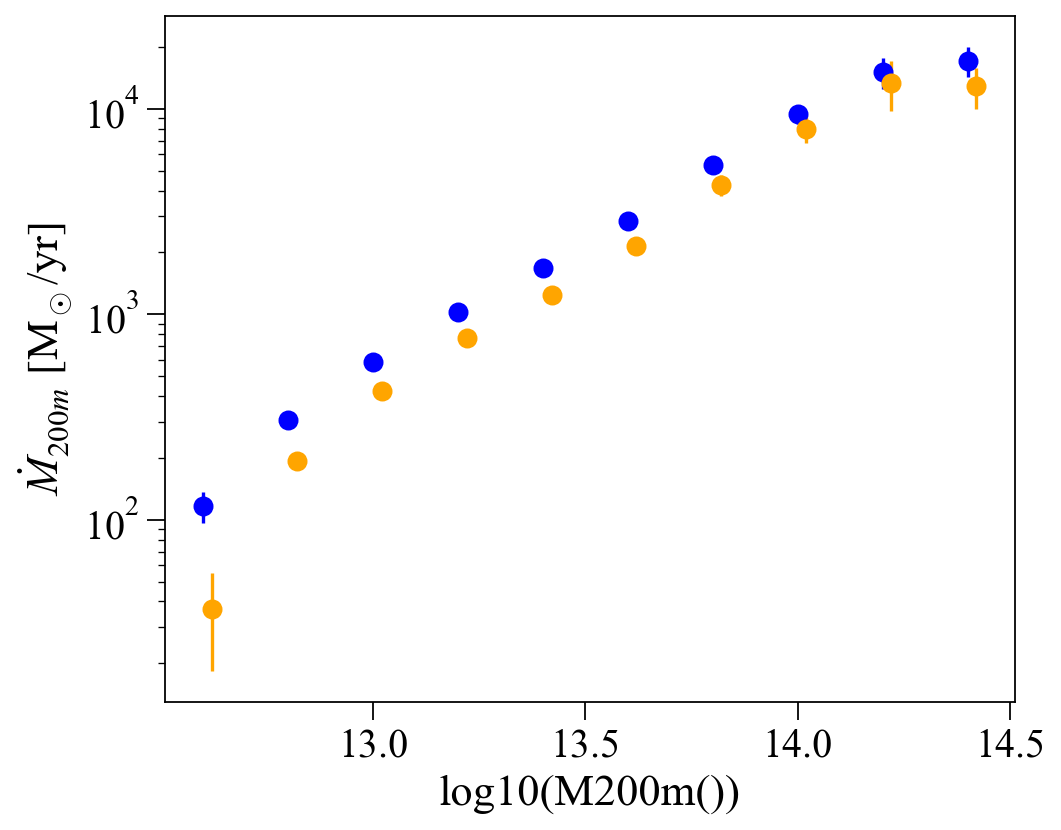

In [7]:
# CHECK \dot{M}_{200m} = 800 \pi \rho_m(z) r_{200m}^2 \dot{r}_{200m} + M_{200m} * \dot{\rho}_m(z) / \rho_m(z)
# using discrete time differences for \dot{r}_200m and \dot{M}_{200m}.

ts_name = '%720%FID%/%8.%'
delta_t_yr = (db.get_timestep(ts_name).time_gyr - db.get_timestep(ts_name).previous.time_gyr)*1e9
z_late = db.get_timestep(ts_name).redshift
z_early = db.get_timestep(ts_name).previous.redshift

 
rho_m_early = ft._cosmic_mean_density(z_early)
rho_m_late = ft._cosmic_mean_density(z_late)

H_z = ft._cosmic_hubble(z_early) 
H_z_yr = H_z * 3.1536e7 / 3.085677581491e19  # in 1/yr

print(f" z_early: {z_early}, z_late: {z_late} ")
print(f" delta log rho_m: {np.log(rho_m_late) - np.log(rho_m_early)} ")
print(f" -3H(z) * delta_t: {-3 * H_z_yr * delta_t_yr} ")
print(f" delta(ln a^3): {3 * np.log((1+z_early)/(1+z_late))} ")

lhs_expr = f'(M200m() - earlier(1).M200m())/({delta_t_yr})'

# log version
#lhs_expr = f'(log(M200m()) - earlier(1).log(M200m()))/({delta_t_yr})'

# EXACT discrete time difference expression - this passes the test perfectly
#rhs_expr = f'({(4./3) * np.pi * 200.0 * rho_m_early} * (r200m**3 - earlier(1).r200m**3) + M200m()*{(rho_m_late - rho_m_early) / rho_m_late}) / {delta_t_yr}'
# log:
#rhs_expr = f'(3*(log(r200m) - earlier(1).log(r200m)) + ( log({rho_m_late}) - log({rho_m_early}) ) ) / {delta_t_yr}'

# APPROXIMATE using linearised r200m diff - this looks not so good
#rhs_expr = f'3.0 * M200m() * ( (r200m - earlier(1).r200m) / (r200m * {delta_t_yr}) ) + (M200m()*{(rho_m_late - rho_m_early) / rho_m_late}) / {delta_t_yr}'

# APPROXIMATE additionally using continuous time derivative for rho_m
rhs_expr = f'3.0 * M200m() * ( (r200m - earlier(1).r200m) / (r200m * {delta_t_yr}) ) + (M200m()*{-3 * H_z_yr})'
# log:
#rhs_expr = f'(3*(log(r200m) - earlier(1).log(r200m))) / {delta_t_yr} - 3 * {H_z_yr}'
print(rhs_expr)

# rhs_expr = f'800 * 3.141592653589793 * {rho_m_z} * (r200m * earlier(1).r200m) * ( (r200m - earlier(1).r200m) / {delta_t_yr} ) - 3 * {H_z_yr} * sqrt(M200m() * earlier(1).M200m())'

fa.make_binned_by_mass_plot(lhs_expr, plot_kwargs={'color': 'blue'}, ts_name = ts_name, error_range='uncertainty', num_bins=10)
fa.make_binned_by_mass_plot(rhs_expr, plot_kwargs={'color': 'orange'}, ts_name = ts_name, error_range='uncertainty', num_bins=10, x_offset=0.02)
p.title("")
p.semilogy()
p.ylabel(r'$\dot{M}_{200m}$ [M$_\odot$/yr]')
